In [1]:
import cmath
import math

import numpy as np

import meep as mp
import matplotlib.pyplot as plt

resolution = 50  # pixels/μm

dpml = 1.0  # PML thickness
dsub = 3.0  # substrate thickness
dpad = 3.0  # length of padding between grating and PML
gp = 10.0  # grating period
gh = 0.5  # grating height
gdc = 0.5  # grating duty cycle

sx = dpml + dsub + gh + dpad + dpml
sy = gp

cell_size = mp.Vector3(sx, sy, 0)
pml_layers = [mp.PML(thickness=dpml, direction=mp.X)]

wvl = 0.5  # center wavelength
fcen = 1 / wvl  # center frequency
df = 0.05 * fcen  # frequency width

ng = 1.5
glass = mp.Medium(index=ng)

use_cw_solver = False  # CW solver or time stepping?
tol = 1e-6  # CW solver tolerance
max_iters = 2000  # CW solver max iterations
L = 10  # CW solver L

# rotation angle of incident planewave; counter clockwise (CCW) about Z axis, 0 degrees along +X axis
theta_in = math.radians(0.01)

# k (in source medium) with correct length (plane of incidence: XY)
k = mp.Vector3(fcen * ng,0,0).rotate(mp.Vector3(z=1), theta_in)

symmetries = []
eig_parity = mp.ODD_Z
if theta_in == 0:
    k = mp.Vector3(0, 0, 0)
    symmetries = [mp.Mirror(mp.Y)]
    eig_parity += mp.EVEN_Y


def pw_amp(k, x0):
    def _pw_amp(x):
        return cmath.exp(1j * 2 * math.pi * k.dot(x + x0))

    return _pw_amp


src_pt = mp.Vector3(-0.5 * sx + dpml + 0.3 * dsub, 0, 0)
sources = [
    mp.Source(
        mp.ContinuousSource(fcen, fwidth=df)
        if use_cw_solver
        else mp.GaussianSource(fcen, fwidth=df),
        component=mp.Ez,
        center=src_pt,
        size=mp.Vector3(0, sy, 0),
        amp_func=pw_amp(k, src_pt),
    )
]

sim = mp.Simulation(
    resolution=resolution,
    cell_size=cell_size,
    boundary_layers=pml_layers,
    k_point=k,
    default_material=glass,
    sources=sources,
    symmetries=symmetries,
)

refl_pt = mp.Vector3(-0.5 * sx + dpml + 0.5 * dsub, 0, 0)
refl_flux = sim.add_flux(
    fcen, 0, 1, mp.FluxRegion(center=refl_pt, size=mp.Vector3(0, sy, 0))
)

if use_cw_solver:
    sim.init_sim()
    sim.solve_cw(tol, max_iters, L)
else:
    sim.run(until_after_sources=100)

input_flux = mp.get_fluxes(refl_flux)
input_flux_data = sim.get_flux_data(refl_flux)

sim.reset_meep()

geometry = [
    mp.Block(
        material=glass,
        size=mp.Vector3(dpml + dsub, mp.inf, mp.inf),
        center=mp.Vector3(-0.5 * sx + 0.5 * (dpml + dsub), 0, 0),
    ),
    mp.Block(
        material=glass,
        size=mp.Vector3(gh, gdc * gp, mp.inf),
        center=mp.Vector3(-0.5 * sx + dpml + dsub + 0.5 * gh, 0, 0),
    ),
]

sim = mp.Simulation(
    resolution=resolution,
    cell_size=cell_size,
    boundary_layers=pml_layers,
    geometry=geometry,
    k_point=k,
    sources=sources,
    symmetries=symmetries,
)

refl_flux = sim.add_flux(
    fcen, 0, 1, mp.FluxRegion(center=refl_pt, size=mp.Vector3(0, sy, 0))
)
sim.load_minus_flux_data(refl_flux, input_flux_data)

tran_pt = mp.Vector3(0.5 * sx - dpml - 0.5 * dpad, 0, 0)
tran_flux = sim.add_flux(
    fcen, 0, 1, mp.FluxRegion(center=tran_pt, size=mp.Vector3(0, sy, 0))
)

if use_cw_solver:
    sim.init_sim()
    sim.solve_cw(tol, max_iters, L)
else:
    sim.run(until_after_sources=200)

nm_r = np.floor((fcen * ng - k.y) * gp) - np.ceil(
    (-fcen * ng - k.y) * gp
)  # number of reflected orders
if theta_in == 0:
    nm_r = nm_r / 2  # since eig_parity removes degeneracy in y-direction
nm_r = int(nm_r)

res = sim.get_eigenmode_coefficients(
    refl_flux, range(1, nm_r + 1), eig_parity=eig_parity
)
r_coeffs = res.alpha

Rsum = 0
for nm in range(nm_r):
    r_kdom = res.kdom[nm]
    Rmode = abs(r_coeffs[nm, 0, 1]) ** 2 / input_flux[0]
    r_angle = np.sign(r_kdom.y) * math.acos(r_kdom.x / (ng * fcen))
    print(f"refl:, {nm:2d}, {math.degrees(r_angle):6.2f}, {Rmode:.8f}")
    Rsum += Rmode

nm_t = np.floor((fcen - k.y) * gp) - np.ceil(
    (-fcen - k.y) * gp
)  # number of transmitted orders
if theta_in == 0:
    nm_t = nm_t / 2  # since eig_parity removes degeneracy in y-direction
nm_t = int(nm_t)

res = sim.get_eigenmode_coefficients(
    tran_flux, range(1, nm_t + 1), eig_parity=eig_parity
)
t_coeffs = res.alpha

Tsum = 0
for nm in range(nm_t):
    t_kdom = res.kdom[nm]
    Tmode = abs(t_coeffs[nm, 0, 0]) ** 2 / input_flux[0]
    t_angle = np.sign(t_kdom.y) * math.acos(t_kdom.x / fcen)
    print(f"tran:, {nm:2d}, {math.degrees(t_angle):6.2f}, {Tmode:.8f}")
    Tsum += Tmode

print(f"mode-coeff:, {Rsum:11.6f}, {Tsum:.6f}, {Rsum + Tsum:.6f}")

r_flux = mp.get_fluxes(refl_flux)
t_flux = mp.get_fluxes(tran_flux)
Rflux = -r_flux[0] / input_flux[0]
Tflux = t_flux[0] / input_flux[0]
print(f"poynting-flux:, {Rflux:.6f}, {Tflux:.6f}, {Rflux + Tflux:.6f}")

-----------
Initializing structure...
time for choose_chunkdivision = 2.7895e-05 s
Working in 2D dimensions.
Computational cell is 8.5 x 10 x 0 with resolution 50
time for set_epsilon = 0.069428 s
-----------
Meep: using complex fields.


FloatProgress(value=0.0, description='0% done ', max=200.0)

Meep progress: 56.31/200.0 = 28.2% done in 4.0s, 10.2s to go
on time step 5633 (time=56.33), 0.000710171 s/step
Meep progress: 114.0/200.0 = 57.0% done in 8.0s, 6.0s to go
on time step 11403 (time=114.03), 0.000693292 s/step
Meep progress: 171.82/200.0 = 85.9% done in 12.0s, 2.0s to go
on time step 17185 (time=171.85), 0.000691823 s/step
run 0 finished at t = 200.0 (20000 timesteps)
-----------
Initializing structure...
time for choose_chunkdivision = 3.31402e-05 s
Working in 2D dimensions.
Computational cell is 8.5 x 10 x 0 with resolution 50
     block, center = (-2.25,0,0)
          size (4,1e+20,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.25,2.25,2.25)
     block, center = (0,0,0)
          size (0.5,5,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.25,2.25,2.25)
time for set_epsilon = 0.107482 s
-----------
Meep: using complex fields.


FloatProgress(value=0.0, description='0% done ', max=300.0)

Meep progress: 59.160000000000004/300.0 = 19.7% done in 4.0s, 16.3s to go
on time step 5917 (time=59.17), 0.000676086 s/step
Meep progress: 119.91/300.0 = 40.0% done in 8.0s, 12.0s to go
on time step 11993 (time=119.93), 0.000658428 s/step
Meep progress: 177.74/300.0 = 59.2% done in 12.0s, 8.3s to go
on time step 17777 (time=177.77), 0.000691638 s/step
Meep progress: 236.98000000000002/300.0 = 79.0% done in 16.0s, 4.3s to go
on time step 23701 (time=237.01), 0.000675221 s/step
Meep progress: 294.52/300.0 = 98.2% done in 20.0s, 0.4s to go
on time step 29455 (time=294.55), 0.000695184 s/step
run 0 finished at t = 300.0 (30000 timesteps)
MPB solved for frequency_1(3,0.000523599,0) = 2 after 117 iters
MPB solved for frequency_1(3,0.000523599,0) = 2 after 1 iters
Dominant planewave for band 1: (3.000000,0.000524,0.000000)
MPB solved for frequency_2(3,0.000523599,0) = 2.0011 after 515 iters
MPB solved for frequency_2(2.99835,0.000523599,0) = 2 after 1 iters
MPB solved for frequency_2(2.99835

     block, center = (-2.25,0,0)
          size (4,1e+20,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.25,2.25,2.25)
     block, center = (0,0,0)
          size (0.5,5,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.25,2.25,2.25)
     block, center = (-2.25,0,0)
          size (4,1e+20,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.25,2.25,2.25)
     block, center = (0,0,0)
          size (0.5,5,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.25,2.25,2.25)
     block, center = (-2.25,0,0)
          size (4,1e+20,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.25,2.25,2.25)
     block, center = (0,0,0)
          size (0.5,5,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.25,2.2

<Axes: xlabel='X', ylabel='Y'>

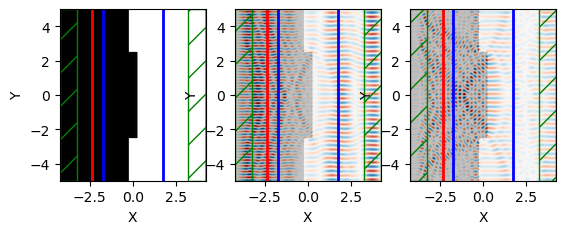

In [2]:
fig, ax = plt.subplots(1,3)
sim.plot2D(ax=ax[0])
sim.plot2D(fields = mp.Ez, ax=ax[1])
sim.plot2D(fields = mp.Hy, ax = ax[2])